In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Folder Names Fix

In [ ]:
BASE_PATH = '/content/drive/MyDrive/dataset'

def fix_folder_names(base):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base, split)
        if not os.path.exists(split_path):
            continue
        for folder in os.listdir(split_path):
            old_path = os.path.join(split_path, folder)
            if not os.path.isdir(old_path):
                continue
            # spaces ko underscore, sab lowercase
            new_name = folder.lower().replace(' ', '_')
            new_path = os.path.join(split_path, new_name)
            if old_path != new_path:
                os.rename(old_path, new_path)
                print(f'Renamed: {folder} -> {new_name}')
            else:
                print(f'OK: {folder}')

fix_folder_names(BASE_PATH)
print('\nFolder names fixed!')

Renamed: Shahbaz Sharif -> shahbaz_sharif
Renamed: Shah Mehmood Quereshi -> shah_mehmood_quereshi
Renamed: Nawaz Sharif -> nawaz_sharif
Renamed: Rana Sanaullah -> rana_sanaullah
OK: asif_ali_zardari
Renamed: Assad Umar -> assad_umar
Renamed: Chaudhary Pervaiz Elahi -> chaudhary_pervaiz_elahi
OK: imran_khan
Renamed: Khurshid Shah -> khurshid_shah
Renamed: Ishaq Dar -> ishaq_dar
Renamed: Maryam Nawaz -> maryam_nawaz
Renamed: Maulana Fazl-ur-Rehman -> maulana_fazl-ur-rehman
Renamed: Bilawal Bhutto Zardari -> bilawal_bhutto_zardari
Renamed: Chaudhary Nisar -> chaudhary_nisar
Renamed: Ahmed Sharif Chaudhary -> ahmed_sharif_chaudhary
Renamed: Aitzaz Ahsan -> aitzaz_ahsan
Renamed: Shahbaz Sharif -> shahbaz_sharif
OK: imran_khan
Renamed: Chaudhary Pervaiz Elahi -> chaudhary_pervaiz_elahi
Renamed: Ishaq Dar -> ishaq_dar
Renamed: Khurshid Shah -> khurshid_shah
Renamed: Maryam Nawaz -> maryam_nawaz
Renamed: Rana Sanaullah -> rana_sanaullah
Renamed: Nawaz Sharif -> nawaz_sharif
Renamed: Maulana Fa

## Dataset

In [ ]:
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR   = os.path.join(BASE_PATH, 'val')
TEST_DIR  = os.path.join(BASE_PATH, 'test')

print(f'{"Split":8s} | {"Classes":>8} | {"Images":>8}')
print('-' * 30)
for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    count   = sum([len(files) for _, _, files in os.walk(d)])
    classes = len([f for f in os.listdir(d) if os.path.isdir(os.path.join(d, f))])
    print(f'{split:8s} | {classes:>8} | {count:>8}')

print('\nClass names:')
for c in sorted(os.listdir(TRAIN_DIR)):
    n = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    print(f'  {c:35s} {n} images')

Split    |  Classes |   Images
------------------------------
train    |       16 |      993
val      |       16 |      200
test     |       16 |      138

Class names:
  ahmed_sharif_chaudhary              60 images
  aitzaz_ahsan                        60 images
  asif_ali_zardari                    64 images
  assad_umar                          60 images
  bilawal_bhutto_zardari              60 images
  chaudhary_nisar                     60 images
  chaudhary_pervaiz_elahi             60 images
  imran_khan                          79 images
  ishaq_dar                           60 images
  khurshid_shah                       60 images
  maryam_nawaz                        64 images
  maulana_fazl-ur-rehman              60 images
  nawaz_sharif                        63 images
  rana_sanaullah                      60 images
  shah_mehmood_quereshi               60 images
  shahbaz_sharif                      63 images


## Transforms & DataLoaders

In [ ]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 25
NUM_CLASSES = 16


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)
print(f'Total classes: {NUM_CLASSES}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Total classes: 16
Train: 993 | Val: 200 | Test: 138


## Samples

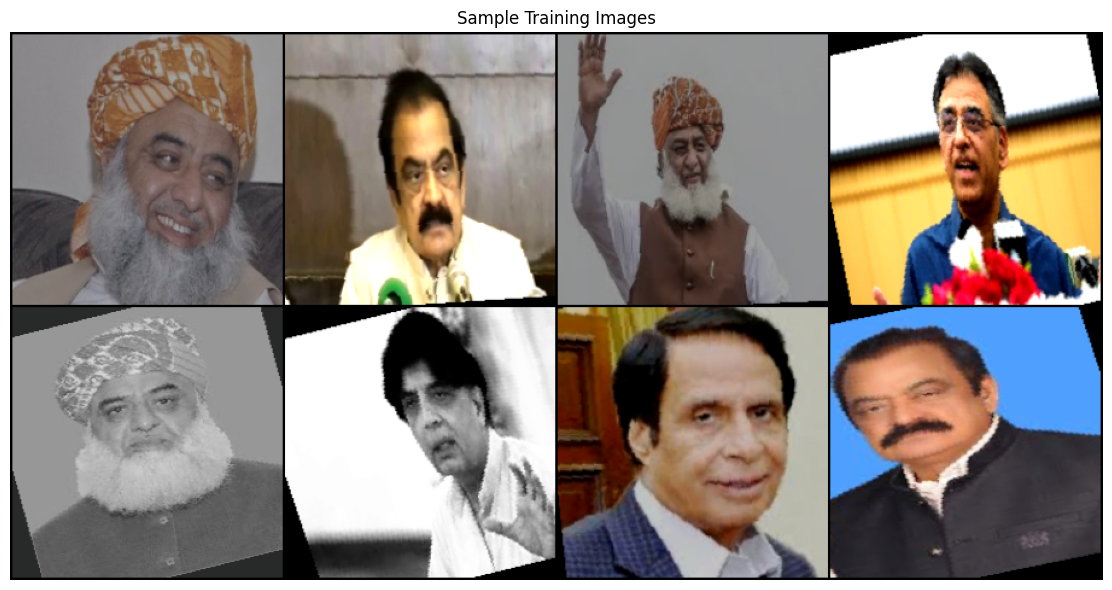

Labels: ['maulana_fazl-ur-rehman', 'rana_sanaullah', 'maulana_fazl-ur-rehman', 'assad_umar', 'maulana_fazl-ur-rehman', 'chaudhary_nisar', 'chaudhary_pervaiz_elahi', 'rana_sanaullah']


In [ ]:
def imshow_grid(loader, class_names, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images = torch.clamp(images * std + mean, 0, 1)
    grid = make_grid(images, nrow=4)
    plt.figure(figsize=(14, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title('Sample Training Images')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print('Labels:', [class_names[l] for l in labels.tolist()])

imshow_grid(train_loader, class_names)

## resnet50

In [ ]:
def get_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

print('Models defined!')

Models defined!


In [ ]:
def train_model(model, model_name, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, lr=0.001):

    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader,
                                   desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs}',
                                   leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds      = torch.max(outputs, 1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                val_loss      += loss.item() * images.size(0)
                _, preds       = torch.max(outputs, 1)
                val_correct   += (preds == labels).sum().item()
                val_total     += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch+1:02d} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy [{model_name}]: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    return model, history

In [ ]:
resnet_model = get_resnet50(NUM_CLASSES)
resnet_model, resnet_history = train_model(
    resnet_model, 'ResNet-50',
    train_loader, val_loader,
    num_epochs=NUM_EPOCHS
)

Epoch 01 | Train Loss: 2.1350 Acc: 0.3827 | Val Loss: 1.9948 Acc: 0.5650


Epoch 02 | Train Loss: 1.3920 Acc: 0.7009 | Val Loss: 1.8565 Acc: 0.7100


Epoch 03 | Train Loss: 1.1278 Acc: 0.8056 | Val Loss: 1.2500 Acc: 0.7900


Epoch 04 | Train Loss: 1.0337 Acc: 0.8570 | Val Loss: 0.9730 Acc: 0.8900


Epoch 05 | Train Loss: 0.9136 Acc: 0.9043 | Val Loss: 1.0976 Acc: 0.8650


...

Epoch 21 | Train Loss: 0.6433 Acc: 0.9960 | Val Loss: 0.6905 Acc: 0.9650


Epoch 22 | Train Loss: 0.6296 Acc: 0.9980 | Val Loss: 0.6903 Acc: 0.9650


Epoch 23 | Train Loss: 0.6365 Acc: 0.9940 | Val Loss: 0.6963 Acc: 0.9650


Epoch 24 | Train Loss: 0.6308 Acc: 0.9970 | Val Loss: 0.6869 Acc: 0.9650


Epoch 25 | Train Loss: 0.6386 Acc: 0.9909 | Val Loss: 0.6924 Acc: 0.9600

Best Val Accuracy [ResNet-50]: 0.9700 (97.00%)


In [ ]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_acc']) + 1)

    axes[0].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
    axes[0].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
    axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90% target')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[1].plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


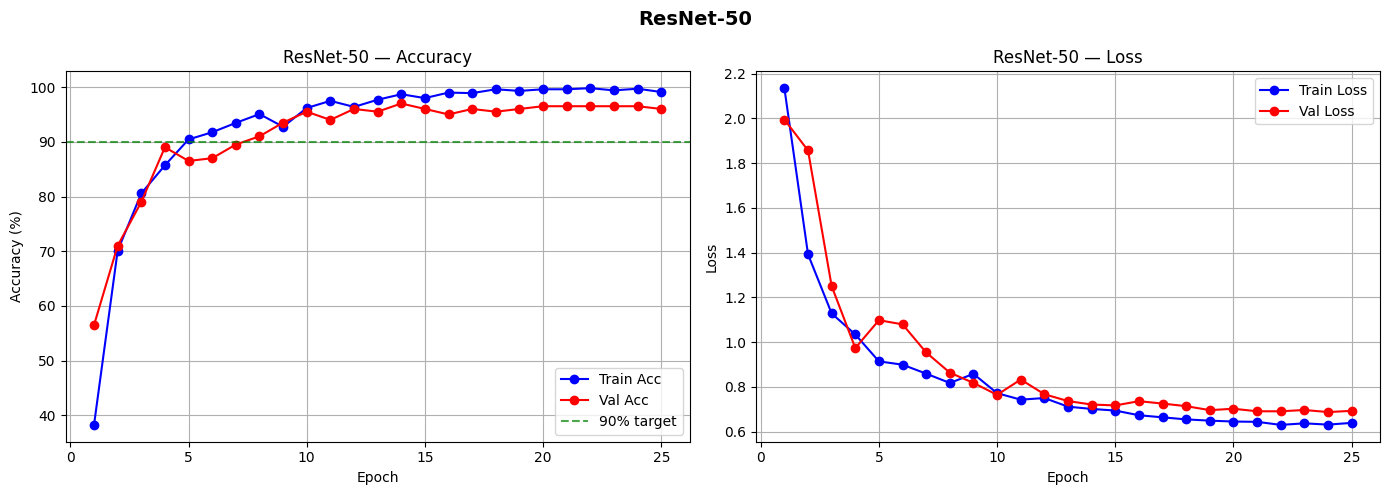

In [ ]:
plot_history(resnet_history, 'ResNet-50')

In [ ]:
def evaluate_model(model, test_loader, class_names, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            images   = images.to(device)
            outputs  = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')

    print(f'Test Results')
    print(f'Overall Accuracy : {acc*100:.2f}%')
    print(f'Weighted F1-Score: {f1:.4f}')
    print(f'\nPer-Class Report:')
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names, digits=4
    ))
    return all_labels, all_preds, acc, f1

In [ ]:
r_labels, r_preds, r_acc, r_f1 = evaluate_model(
    resnet_model, test_loader, class_names, 'ResNet-50'
)

Testing ResNet-50: 100%|██████████| 5/5 [00:03<00:00,  1.25it/s]

Test Results
Overall Accuracy : 94.93%
Weighted F1-Score: 0.9488

Per-Class Report:
                         precision    recall  f1-score   support

 ahmed_sharif_chaudhary     1.0000    1.0000    1.0000         9
           aitzaz_ahsan     0.8889    1.0000    0.9412         8
       asif_ali_zardari     0.8750    0.7778    0.8235         9
             assad_umar     0.8889    1.0000    0.9412         8
 bilawal_bhutto_zardari     1.0000    1.0000    1.0000         8
        chaudhary_nisar     1.0000    1.0000    1.0000         8
chaudhary_pervaiz_elahi     1.0000    0.8750    0.9333         8
             imran_khan     1.0000    0.9091    0.9524        11
              ishaq_dar     0.9000    1.0000    0.9474         9
          khurshid_shah     0.8750    0.8750    0.8750         8
           maryam_nawaz     0.9000    1.0000    0.9474         9
 maulana_fazl-ur-rehman     1.0000    1.0000    1.0000         8
           nawaz_sharif     1.0000    1.0000    1.0000         9
     

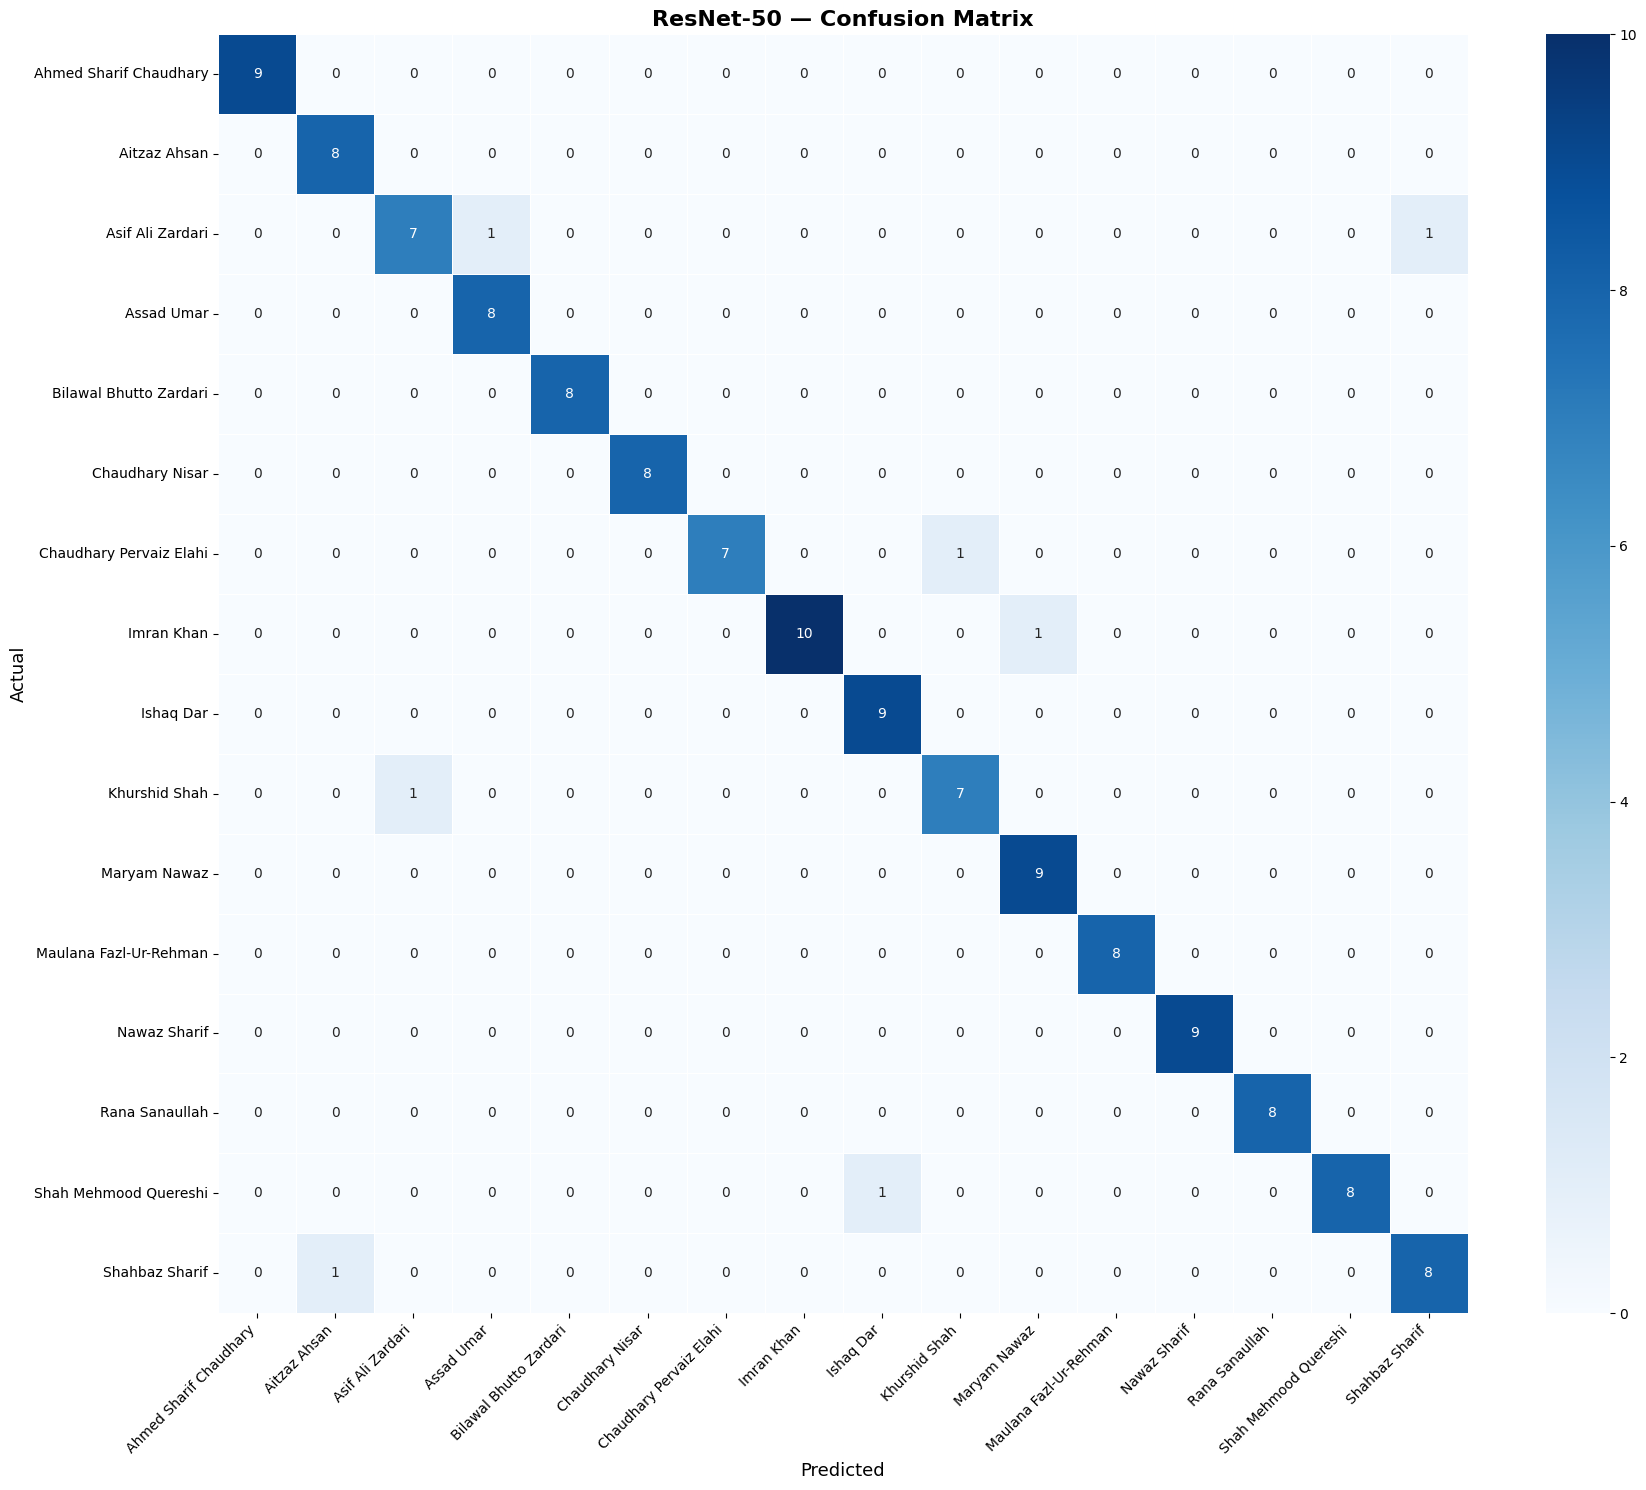

In [ ]:
def plot_confusion_matrix(labels, preds, class_names, model_name):
    cm = confusion_matrix(labels, preds)
    pretty_names = [c.replace('_', ' ').title() for c in class_names]
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=pretty_names,
                yticklabels=pretty_names,
                linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('Actual', fontsize=13)
    plt.xlabel('Predicted', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_confusion_matrix.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(r_labels, r_preds, class_names, 'ResNet-50')


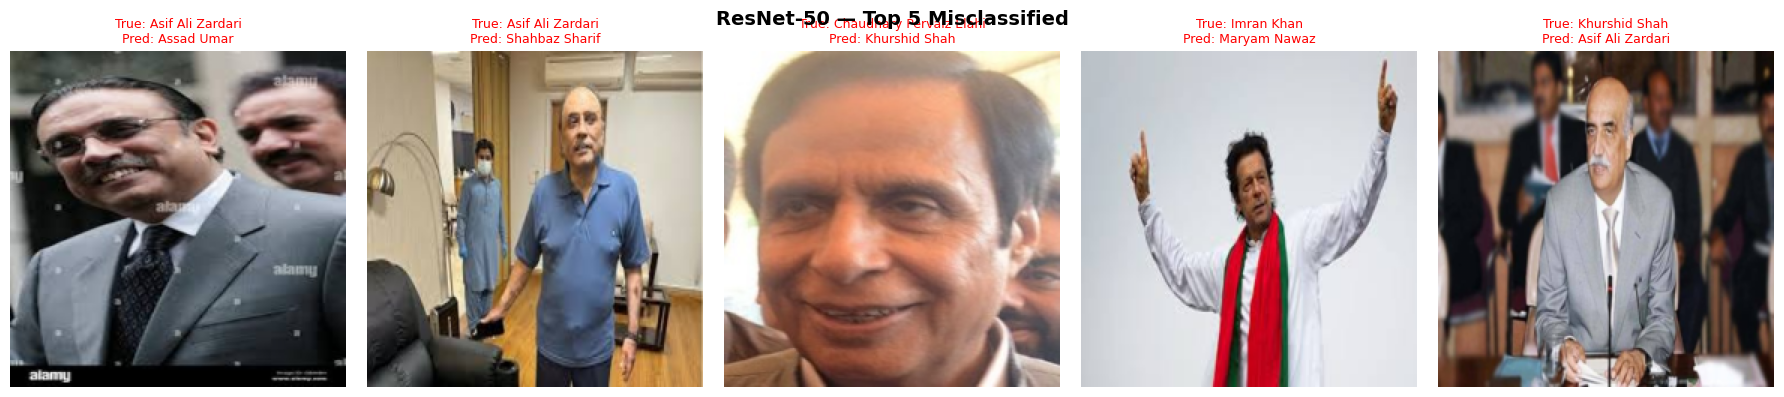

In [ ]:
def show_misclassified(model, test_loader, class_names, model_name, top_n=5):
    model.eval()
    misclassified_imgs = []
    misclassified_true = []
    misclassified_pred = []

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs    = model(images_dev)
            _, preds   = torch.max(outputs, 1)
            preds_cpu  = preds.cpu()

            wrong_idx = (preds_cpu != labels).nonzero(as_tuple=True)[0]
            for idx in wrong_idx:
                if len(misclassified_imgs) >= top_n:
                    break
                img = torch.clamp(images[idx] * std + mean, 0, 1)
                misclassified_imgs.append(img)
                misclassified_true.append(labels[idx].item())
                misclassified_pred.append(preds_cpu[idx].item())
            if len(misclassified_imgs) >= top_n:
                break

    if len(misclassified_imgs) == 0:
        print('Koi misclassified sample nahi mila — 100% accuracy!')
        return

    fig, axes = plt.subplots(1, min(top_n, len(misclassified_imgs)), figsize=(18, 4))
    if top_n == 1:
        axes = [axes]
    fig.suptitle(f'{model_name} — Top {top_n} Misclassified', fontsize=14, fontweight='bold')
    for i in range(len(misclassified_imgs)):
        axes[i].imshow(misclassified_imgs[i].permute(1, 2, 0))
        true_name = class_names[misclassified_true[i]].replace('_',' ').title()
        pred_name = class_names[misclassified_pred[i]].replace('_',' ').title()
        axes[i].set_title(f'True: {true_name}\nPred: {pred_name}',
                          fontsize=9, color='red')
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_misclassified.png',
                dpi=150, bbox_inches='tight')
    plt.show()

show_misclassified(resnet_model, test_loader, class_names, 'ResNet-50')
